In [1]:
! pip install fipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 7.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# time (seconds)
t = np.array([5,10,15,20,25,30,35,40,45,50,55,60,70,80,90,100,110,120,130,140])

# average length (µm)
L_um = np.array([
22.9005	,31.0505	,39.4735	,47.8235	,45.0545	,47.76825,	54.10075,
53.82525,56.67725,	56.876,	58.0475	,59.49225	,61.97375	,67.22966667,
68.70333333	,73.095	,86.4415,	77.7165	,73.521	,68.5755
])

# convert to meters
L = L_um * 1e-6

Here we use the average values extracted from the microscopic images

In [4]:
L2 = L**2

# linear fit
coeff = np.polyfit(t, L2, 1)

D = coeff[0]

print("Diffusion coefficient:", D)

Diffusion coefficient: 3.822908502158075e-11


remember the diffusion law is a partial differential equation -applying diffusion growth law

𝐿^2=𝐷𝑡


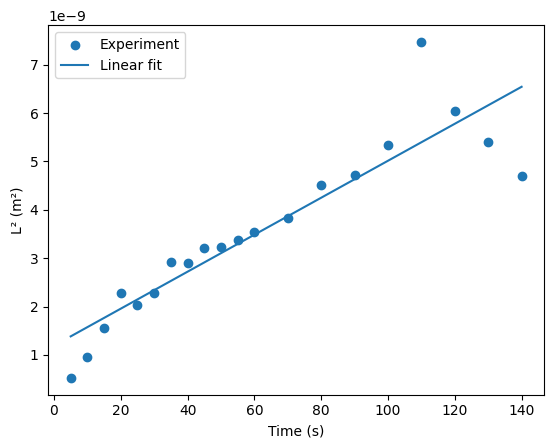

In [5]:
plt.scatter(t, L2, label="Experiment")

plt.plot(t, coeff[0]*t + coeff[1],
         label="Linear fit")

plt.xlabel("Time (s)")
plt.ylabel("L² (m²)")
plt.legend()
plt.show()

In [10]:
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm

# domain
length_domain = 200e-6
nx = 200
dx = length_domain / nx

mesh = Grid1D(nx=nx, dx=dx)

# concentration field
C = CellVariable(mesh=mesh, value=0.)

# diffusion coefficient
D = 3.82e-11

# diffusion equation
eq = TransientTerm() == DiffusionTerm(coeff=D)

# reservoir boundary
C.constrain(1.0, mesh.facesLeft)

dt = 0.5
steps = 300

tube_length = []
time = []

for step in range(steps):

    eq.solve(var=C, dt=dt)

    # estimate tube length
    L_tube = np.sum(C.value > 0.2) * dx

    tube_length.append(L_tube)
    time.append(step * dt)

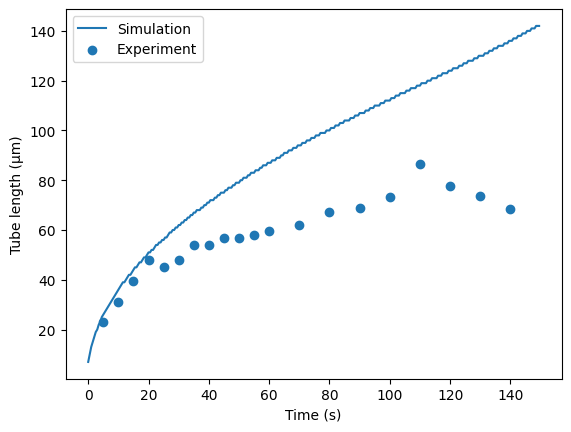

In [11]:
plt.plot(time, np.array(tube_length)*1e6,
         label="Simulation")

plt.scatter(t, L_um,
            label="Experiment")

plt.xlabel("Time (s)")
plt.ylabel("Tube length (µm)")
plt.legend()
plt.show()

now we simulate and we will compare experimental vs simualtion above script does the finite simulation based of the diffusion law